This notebook contains some naive implementations of attention mechanisms for an LLM

In [10]:
import numpy as np
from Tokenizers import TokenizerV1 as tok 


#Test sentence:
Text = "To be or not to be?"
Tokenizer =tok.My_tokenizer()
cleaned=Tokenizer.clean_up(Text)
vocab,eos=Tokenizer.fit(cleaned,6)


Tokens = Tokenizer.transform(cleaned)

#Intial embedding:

Embed=tok.Simple_embedding(5,len(vocab.keys()))
Embed.initialize()

Fitted!
Text out of vocabulary: 0.0


array([[-0.18694086, -0.46244298,  0.08313792,  1.20599876, -0.34430671],
       [ 0.35808641,  0.00779722,  1.43741497,  0.35011295, -0.43677533],
       [ 0.44056762,  0.36436182, -1.42791364,  0.06791754,  0.26795067],
       [ 1.26561717, -1.09020602,  1.17405711, -0.0329385 , -0.82020432],
       [-0.04966122, -0.33271849,  1.72251986, -0.40666921, -1.71258052],
       [ 0.23892786, -0.17797285,  0.73860244,  1.10137104, -0.8035537 ],
       [ 0.58355086, -2.52846045,  0.66704475, -0.35555842, -0.39620648]])

In [11]:
#Embedding:

Tokens

Embed.set_end_points(eos)
Embedded=Embed.transform(Tokens)


In [3]:
#attention mechanic test:

import jax 
from jax import numpy as jnp


from Attention_Mechanisms.core.transformer_math import dot_product_attention
from Attention_Mechanisms.backends.jax_backend import jax_backend
jx_bknd = jax_backend()

u=jnp.array(Embedded)
dot_product_attention(u,u,u,jx_bknd)

Wrapped functions: ['matmul', 'matrix_exp', 'softmax', 'sqrt', 'transpose', 'where']


Array([[-0.23983264,  0.5609806 ,  1.3389841 ,  0.40581104,  0.32458568],
       [-1.8303702 ,  0.5740541 ,  1.9494729 ,  2.8385575 , -1.2057854 ],
       [-0.6991241 ,  0.3600575 ,  0.3117489 ,  1.3967298 ,  0.09220809],
       [-1.8519717 ,  0.8298691 ,  0.4955449 , -0.11791057,  1.5960793 ],
       [-0.22284691,  0.27419376,  0.01796637,  0.15836437,  1.101852  ],
       [-1.8303702 ,  0.5740541 ,  1.9494729 ,  2.8385575 , -1.2057854 ],
       [-1.119377  ,  0.46607053,  0.9727737 ,  1.6712915 , -0.16020578]],      dtype=float32)

Next up a showcase of the Orhtogonal self-attention at seen in Zhang, Martens et al Feb. 2026:

(
https://doi.org/10.48550/arXiv.2602.05996
)
$OSA(X)= A(X)V = e^{S}V$
where $S= \frac{\alpha}{\sqrt{d}}[QK^T-KQ^T]$ 

In [9]:
from Attention_Mechanisms.core.transformer_math import orthogonal_attention
from Attention_Mechanisms.backends.jax_backend import jax_backend
import jax 
from jax import numpy as jnp
jx_bknd=jax_backend()
v = jnp.array(Embedded)
orthogonal_attention(v,v,v,backend=jx_bknd,alpha=1)



Wrapped functions: ['matmul', 'matrix_exp', 'softmax', 'sqrt', 'transpose', 'where']


Array([[-0.40295982, 10.9321375 ,  3.557571  ,  7.403288  ,  6.2359314 ],
       [-0.40295982, 10.9321375 ,  3.557571  ,  7.403288  ,  6.2359314 ],
       [-0.40295982, 10.9321375 ,  3.557571  ,  7.403288  ,  6.2359314 ],
       [-0.40295982, 10.9321375 ,  3.557571  ,  7.403288  ,  6.2359314 ],
       [-0.40295982, 10.9321375 ,  3.557571  ,  7.403288  ,  6.2359314 ],
       [-0.40295982, 10.9321375 ,  3.557571  ,  7.403288  ,  6.2359314 ],
       [-0.40295982, 10.9321375 ,  3.557571  ,  7.403288  ,  6.2359314 ]],      dtype=float32)

Quick test on MNIST

In [12]:
from Attention_Mechanisms.core.transformer_math import orthogonal_attention
from Attention_Mechanisms.backends.tf_backend import tf_backend
import tensorflow as tf

tf_bknd=tf_backend()
v = tf.convert_to_tensor(Embedded,dtype=tf.float32)
orthogonal_attention(v,v,v,backend=tf_bknd,alpha=tf.cast(1,dtype=tf.float32))



Wrapped functions: ['matmul', 'matrix_exp', 'softmax', 'sqrt', 'transpose', 'where']


TypeError: `x` and `y` must have the same dtype, got tf.float32 != tf.float64.

In [13]:
import tensorflow_datasets as dataf


(ds_train, ds_test), ds_info = dataf.load(
    'mnist',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)
def normalize_img(image, label):
  """Normalizes images: `uint8` -> `float32`."""
  return tf.cast(image, tf.float32) / 255., label

ds_train = ds_train.map(
    normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_train = ds_train.cache()
ds_train = ds_train.shuffle(ds_info.splits['train'].num_examples)
ds_train = ds_train.batch(128)
ds_train = ds_train.prefetch(tf.data.AUTOTUNE)

In [14]:
ds_test = ds_test.map(
    normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_test = ds_test.batch(128)
ds_test = ds_test.cache()
ds_test = ds_test.prefetch(tf.data.AUTOTUNE)

In [15]:
# Custom layer for MNIST with OSA
from Attention_Mechanisms.core.transformer_math import orthogonal_attention
from Attention_Mechanisms.backends.tf_backend import tf_backend


class Naive_OSA_Layer(tf.keras.layers.Layer):

    def __init__(self, *,num_outputs, activity_regularizer = None, trainable = True, dtype = None, autocast = True, name = None, input_dim = None, input_shape = None):
        
        super().__init__(activity_regularizer=activity_regularizer, trainable=trainable, dtype=dtype, autocast=autocast, name=name, input_dim=input_dim, input_shape=input_shape)
        self.num_outputs = num_outputs
        self.bknd = tf_backend()
        self.W_O =tf.keras.layers.Dense(num_outputs)
   # def build(self,input_shape):
   #     self.kernel = self.add_weight("kernel",
   #                     shape=[int(input_shape[-1]),
   #                     self.num_outputs]
   #                     )
        
    def call(self,inputs):
        attn_out = orthogonal_attention(inputs,inputs,inputs,backend=self.bknd,alpha=tf.cast(1,dtype=tf.float32))
        output = self.W_O(attn_out)
        return output

In [16]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  Naive_OSA_Layer(num_outputs=64),
  tf.keras.layers.Dense(10)
])
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()],
)


history = model.fit(
    ds_train,
    epochs=6,
    validation_data=ds_test,
)

c:\Users\puket\myenv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Wrapped functions: ['matmul', 'matrix_exp', 'softmax', 'sqrt', 'transpose', 'where']




c:\Users\puket\myenv\Lib\site-packages\keras\src\layers\layer.py:1505: UserWarning: Layer 'naive_osa__layer' looks like it has unbuilt state, but Keras is not able to trace the layer `call()` in order to build it automatically. Possible causes:
1. The `call()` method of your layer may be crashing. Try to `__call__()` the layer eagerly on some test input first to see if it works. E.g. `x = np.random.random((3, 4)); y = layer(x)`
2. If the `call()` method is correct, then you may need to implement the `def build(self, input_shape)` method on your layer. It should create all variables used by the layer (e.g. by calling `layer.build()` on all its children layers).
Exception encountered: ''`x` and `y` must have the same dtype, got tf.float32 != tf.float64.''
  warnings.warn(
c:\Users\puket\myenv\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'naive_osa__layer', however the layer does not have a `build()` method implemented and it looks like it h

TypeError: Exception encountered when calling Naive_OSA_Layer.call().

[1mCould not automatically infer the output shape / dtype of 'naive_osa__layer' (of type Naive_OSA_Layer). Either the `Naive_OSA_Layer.call()` method is incorrect, or you need to implement the `Naive_OSA_Layer.compute_output_spec() / compute_output_shape()` method. Error encountered:

`x` and `y` must have the same dtype, got tf.float32 != tf.float64.[0m

Arguments received by Naive_OSA_Layer.call():
  • args=('<KerasTensor shape=(None, 784), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1>',)
  • kwargs=<class 'inspect._empty'>

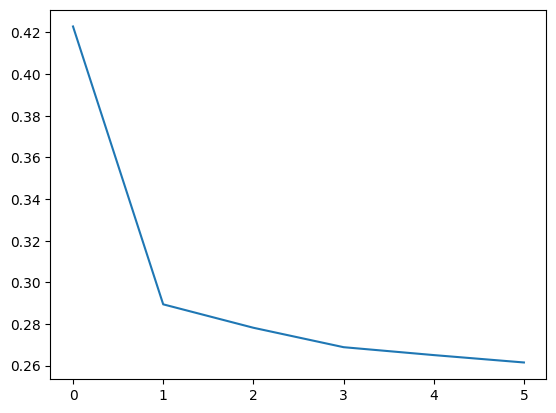

In [28]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label= "Training_loss")
plt.show()

In [29]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ naive_osa__layer_5              │ (None, 64)             │        50,240 │
│ (Naive_OSA_Layer)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)